In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import torch
from datasets import Dataset, Audio
from sklearn.model_selection import train_test_split
from transformers import (
    Wav2Vec2FeatureExtractor, 
    Wav2Vec2ForSequenceClassification, 
    TrainingArguments, 
    Trainer
)

# Target the M3 Pro GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Our specific 5 emotions
target_map = {'happy': 0, 'sad': 1, 'angry': 2, 'neutral': 3, 'anxious': 4}
id2label = {v: k for k, v in target_map.items()}
label2id = target_map

/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [3]:
dataset_path = "/Users/neerajprao/Desktop/SoulSync/custom_model/Emotions"

# RAVDESS numerical mapping
ravdess_map = {
    '01': 'neutral',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'anxious' # Mapping 'Fearful' to your 'Anxious' class
}

paths = []
labels = []

# Using os.walk to handle the subfolders (Angry, Happy, etc.)
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            parts = file.split('-')
            
            # Ensure it follows the RAVDESS 7-part format
            if len(parts) >= 3:
                emotion_code = parts[2]
                
                if emotion_code in ravdess_map:
                    paths.append(os.path.join(root, file))
                    labels.append(target_map[ravdess_map[emotion_code]])

df = pd.DataFrame({'path': paths, 'label': labels})

if len(df) == 0:
    print("❌ Still not finding files. Please check if the subfolders contain the .wav files directly.")
else:
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    
    print(f"✅ Success! Found {len(df)} files matching your 5 emotions.")
    print(f"Training samples: {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")
    print("\nDistribution:")
    print(train_df['label'].value_counts().rename(index=id2label))

✅ Success! Found 1692 files matching your 5 emotions.
Training samples: 1353
Validation samples: 339

Distribution:
label
sad        301
happy      301
anxious    301
angry      300
neutral    150
Name: count, dtype: int64


In [5]:
import librosa
import numpy as np

model_checkpoint = "facebook/wav2vec2-base-960h"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_checkpoint)

# Convert DataFrames to HF Datasets (without the 'Audio' cast for now)
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

def preprocess_audio(examples):
    audio_list = []
    for path in examples["path"]:
        # Manually load and resample to 16kHz
        speech_array, sampling_rate = librosa.load(path, sr=16000)
        audio_list.append(speech_array)
    
    inputs = feature_extractor(
        audio_list, 
        sampling_rate=16000, 
        max_length=48000, 
        truncation=True,
        padding="max_length"
    )
    
    inputs["labels"] = examples["label"]
    return inputs

print("Extracting features manually via Librosa...")

# We set num_proc=1 to avoid multiprocessing issues on M3 during the first run
train_encoded = train_ds.map(preprocess_audio, batched=True, batch_size=8, remove_columns=["path", "label"])
val_encoded = val_ds.map(preprocess_audio, batched=True, batch_size=8, remove_columns=["path", "label"])

print("✅ Feature extraction complete.")

Extracting features manually via Librosa...


Map: 100%|██████████| 339/339 [00:00<00:00, 502.06 examples/s]

✅ Feature extraction complete.


In [7]:
# Load the pre-trained model with a classification head
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_checkpoint, 
    num_labels=len(target_map),
    label2id=label2id,
    id2label=id2label
)

# Move the model to your M3 Pro's GPU (MPS)
model.to(device)

# New way to freeze the feature encoder
# This targets the underlying wav2vec2 feature_extractor correctly
model.wav2vec2.feature_extractor._freeze_parameters()

print(f"Model loaded and moved to: {device}")
print(f"Number of trainable parameters: {model.num_parameters(only_trainable=True)}")

Loading weights: 100%|██████████| 210/210 [00:00<00:00, 8923.78it/s]
Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.weight             | UNEXPECTED | 
wav2vec2.masked_spec_embed | MISSING    | 
projector.weight           | MISSING    | 
classifier.weight          | MISSING    | 
projector.bias             | MISSING    | 
classifier.bias            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to: mps
Number of trainable parameters: 90369413


In [9]:
from transformers import TrainingArguments, Trainer
import torch
import numpy as np

# Manual accuracy calculation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": (predictions == labels).astype(np.float32).mean().item()}

training_args = TrainingArguments(
    output_dir="./emotion_model_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=4, 
    gradient_accumulation_steps=4, 
    num_train_epochs=10,           
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none" 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
)

print("🚀 Starting training on M3 Pro GPU...")
trainer.train()

🚀 Starting training on M3 Pro GPU...


/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,6.320620,1.576881,0.318584
2,5.280806,1.329110,0.407080
3,4.750766,1.215184,0.533923
4,4.320206,0.961366,0.625369
5,3.387189,0.784482,0.731563
6,2.636124,0.677258,0.772861
7,2.377242,0.693413,0.758112
8,2.399700,0.581330,0.811209
9,2.155810,0.557492,0.814159
10,1.980722,0.553405,0.828909


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]
/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.32it/s]
/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.41it/s]
/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00

TrainOutput(global_step=850, training_loss=3.7305100856107822, metrics={'train_runtime': 887.6109, 'train_samples_per_second': 15.243, 'train_steps_per_second': 0.958, 'total_flos': 3.6850470316704e+17, 'train_loss': 3.7305100856107822, 'epoch': 10.0})

In [10]:
# Save the model and feature extractor to a permanent directory
output_dir = "/Users/neerajprao/Desktop/SoulSync/custom_model/final_emotion_model"

model.save_pretrained(output_dir)
feature_extractor.save_pretrained(output_dir)

print(f"✅ Model successfully saved to: {output_dir}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.20it/s]

✅ Model successfully saved to: /Users/neerajprao/Desktop/SoulSync/custom_model/final_emotion_model


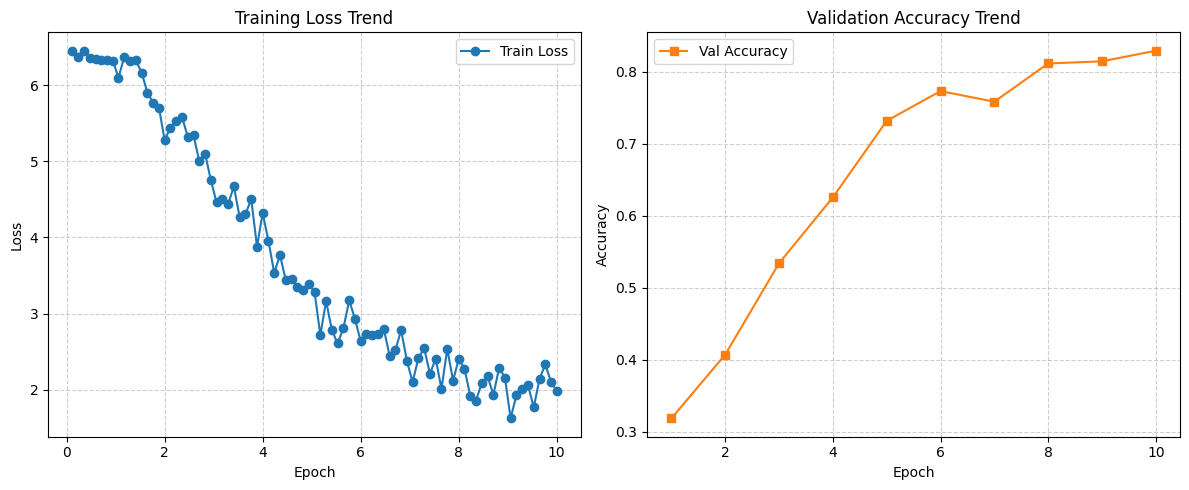


Generating Confusion Matrix...


/Users/neerajprao/Desktop/SoulSync/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


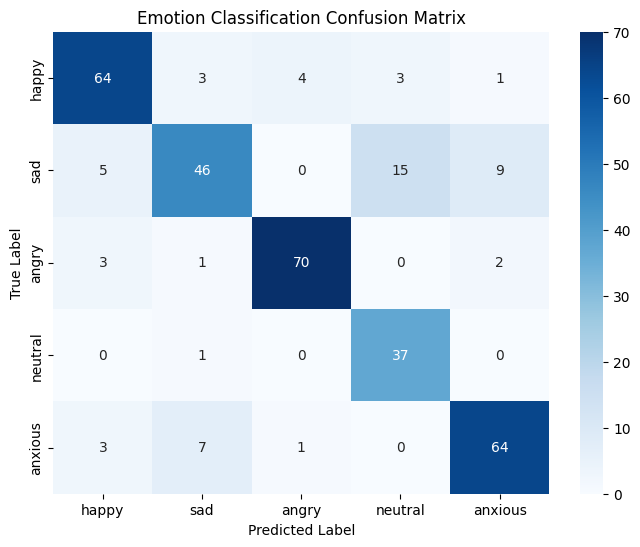


Classification Report:
              precision    recall  f1-score   support

       happy       0.85      0.85      0.85        75
         sad       0.79      0.61      0.69        75
       angry       0.93      0.92      0.93        76
     neutral       0.67      0.97      0.80        38
     anxious       0.84      0.85      0.85        75

    accuracy                           0.83       339
   macro avg       0.82      0.84      0.82       339
weighted avg       0.84      0.83      0.83       339



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Plot Training & Validation Progress
history = trainer.state.log_history

# Extract metrics from history
train_loss = [x['loss'] for x in history if 'loss' in x]
epochs_loss = [x['epoch'] for x in history if 'loss' in x]
val_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]
epochs_acc = [x['epoch'] for x in history if 'eval_accuracy' in x]

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_loss, train_loss, label='Train Loss', color='#1f77b4', marker='o')
plt.title('Training Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_acc, val_acc, label='Val Accuracy', color='#ff7f0e', marker='s')
plt.title('Validation Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# 2. Generate Confusion Matrix
print("\nGenerating Confusion Matrix...")
predictions = trainer.predict(val_encoded)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(target_map.keys()), 
            yticklabels=list(target_map.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Emotion Classification Confusion Matrix')
plt.show()

# 3. Print Detailed Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(target_map.keys())))

In [3]:
import torch
import librosa
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor

# 1. Setup paths and device
model_path = "/Users/neerajprao/Desktop/SoulSync/custom_model/final_emotion_model"
test_audio = "/Users/neerajprao/Downloads/a.wav" # Path to audio file
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 2. Load the model and feature extractor
model = Wav2Vec2ForSequenceClassification.from_pretrained(model_path).to(device)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_path)
model.eval()

# 3. Load audio, extract features, and predict
speech_array, _ = librosa.load(test_audio, sr=16000)
inputs = feature_extractor(speech_array, sampling_rate=16000, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    logits = model(**inputs).logits
    prediction = torch.argmax(logits, dim=-1).item()

# 4. Map back to emotion name using the target_map from your training script
id2label = {0: 'happy', 1: 'sad', 2: 'angry', 3: 'neutral', 4: 'anxious'}
print(f"Detected Emotion: {id2label[prediction]}")

Loading weights: 100%|██████████| 215/215 [00:00<00:00, 10244.89it/s]
/var/folders/tl/l30fm8zn2cz9rqddsqy2jzm00000gn/T/ipykernel_21637/3038520980.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  speech_array, _ = librosa.load(test_audio, sr=16000)


Detected Emotion: sad


In [5]:
import torch
import librosa
import torch.nn.functional as F
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor

# 1. Setup paths and device
model_path = "/Users/neerajprao/Desktop/SoulSync/custom_model/final_emotion_model"
test_audio = "/Users/neerajprao/Downloads/b.wav" 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 2. Load the model and feature extractor
model = Wav2Vec2ForSequenceClassification.from_pretrained(model_path).to(device)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_path)
model.eval()

# 3. Process Audio
speech_array, _ = librosa.load(test_audio, sr=16000)
inputs = feature_extractor(speech_array, sampling_rate=16000, return_tensors="pt", padding=True).to(device)

# 4. Inference and Probability Distribution
with torch.no_grad():
    logits = model(**inputs).logits
    # Apply softmax to get probabilities (0.0 to 1.0)
    probs = F.softmax(logits, dim=-1)

# 5. Display Results
id2label = {0: 'happy', 1: 'sad', 2: 'angry', 3: 'neutral', 4: 'anxious'}
prob_dist = probs[0].cpu().numpy()

print("--- Probability Distribution ---")
for i, prob in enumerate(prob_dist):
    print(f"{id2label[i]:<8}: {prob:>6.2%}")

prediction = torch.argmax(logits, dim=-1).item()
print(f"\nFinal Classification: {id2label[prediction]}")

Loading weights: 100%|██████████| 215/215 [00:00<00:00, 7144.76it/s]
/var/folders/tl/l30fm8zn2cz9rqddsqy2jzm00000gn/T/ipykernel_21637/3717285249.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  speech_array, _ = librosa.load(test_audio, sr=16000)


--- Probability Distribution ---
happy   : 83.33%
sad     :  3.08%
angry   :  5.97%
neutral :  1.64%
anxious :  5.99%

Final Classification: happy
